<a href="https://colab.research.google.com/github/mraj69663-hue/Car-damage-classification-CNN/blob/main/car_damage_cnn_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Damage Assessment with a CNN

## Case study assignment | PyTorch | Google Colab

**Business context.** An automobile insurer wants to speed up first-pass review of vehicle-damage photos. This notebook builds an image classifier that predicts one of the labels present in the supplied CSV. Its output is an assistive triage signal for a human reviewer, not a claim decision.

**What you will build.** A small convolutional neural network (CNN), trained on labeled car images, with a held-out test evaluation, a confusion matrix, and example predictions.

> **Dataset alignment note:** The project brief describes categories by *damage location* (front/rear/side) and *severity* (minor/moderate/severe). The supplied `data.csv` instead labels component/damage types: `bumper_dent`, `bumper_scratch`, `door_dent`, `door_scratch`, `glass_shatter`, `head_lamp`, `tail_lamp`, and `unknown`. This notebook predicts those eight supplied labels. It cannot report front/rear/side or severity because those labels are not present. To meet that exact brief, obtain or create verified location/severity labels first.

### Assignment objectives

1. Inspect and clean the image metadata, including repeated image paths.
2. Explain how convolution, pooling, and a classification layer work together.
3. Split images into train, validation, and test sets without image leakage.
4. Train and evaluate an eight-class CNN using PyTorch.
5. Interpret the results and identify limitations before proposing deployment.

### Reference materials and data

- `Fin_Malaria_Case_study.ipynb` is used as a **workflow example** (preprocessing, CNN training, curves, confusion matrix, and sample predictions). Its malaria-specific paths, labels, and results are not reused.
- `Car damage assessment.pdf` supplies the insurance scenario and intended business categories. The label mismatch with the CSV is described above.
- Dataset folder: `Copy of car-damage-assessment-kaggle-dataset/`, with `data.csv` and `image/`.

### Prepare Google Colab

1. Upload the complete dataset folder to the top level of your Google Drive's `MyDrive` folder. It must contain `data.csv` and the `image/` directory.
2. In Colab, choose **Runtime → Change runtime type → T4 GPU** (optional, but faster).
3. Run cells from top to bottom. In the data configuration cell, adjust `DATA_ROOT` if you chose a different Drive folder.

The Windows paths supplied with the request (`C:\Users\mraj6\Downloads\...`) are local to that computer and are not directly visible to a Colab runtime.

## 1. How a CNN learns from an image

A CNN applies small learned filters across an image. Early filters can respond to edges and color changes; deeper layers combine these into patterns such as dents, broken glass, or lamps. Pooling reduces spatial size, and a final linear layer produces one score (logit) per class. Softmax turns the scores into class probabilities. During training, cross-entropy loss compares the logits with the known label, and backpropagation updates the filters to reduce that loss.

In [2]:
# Google Colab: connect to the Drive folder containing data.csv and image/
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Update this path if you uploaded the data folder somewhere else in MyDrive.
from pathlib import Path
DATA_ROOT = Path('/content/drive/MyDrive/Copy of car-damage-assessment-kaggle-dataset')
CSV_PATH = DATA_ROOT / 'data.csv'
IMAGE_DIR = DATA_ROOT / 'image'

assert CSV_PATH.exists(), f'Could not find {CSV_PATH}. Check DATA_ROOT.'
assert IMAGE_DIR.is_dir(), f'Could not find image folder: {IMAGE_DIR}'
print('Dataset folder:', DATA_ROOT)


Dataset folder: /content/drive/MyDrive/Copy of car-damage-assessment-kaggle-dataset


In [4]:
# Imports and repeatable experiment setup #Activate CUDA
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)


PyTorch: 2.11.0+cu128
Device: cuda


## 2. Load and inspect the labels

The CSV stores a relative image path and a class name. We remove the CSV index column if present. The supplied metadata includes repeated image paths; repeated images must be deduplicated **before** splitting, or copies could leak between training and testing.

In [5]:
df = pd.read_csv(CSV_PATH)
# CSV export may include an unnecessary row-number column.
df = df.loc[:, ~df.columns.str.match(r'^Unnamed')]
required = {'image', 'classes'}
assert required.issubset(df.columns), f'Expected columns {required}; found {df.columns.tolist()}'
df = df[['image', 'classes']].dropna().copy()
df['image'] = df['image'].astype(str)
df['classes'] = df['classes'].astype(str)

# Verify that each image has one label, then keep one row per unique image.
labels_per_image = df.groupby('image')['classes'].nunique()
assert (labels_per_image == 1).all(), 'At least one image has conflicting labels; inspect the CSV.'
rows_before = len(df)
df = df.drop_duplicates(subset='image').reset_index(drop=True)
print(f'Rows before deduplication: {rows_before:,}')
print(f'Unique labeled images: {len(df):,}')
print(f'Repeated image rows removed: {rows_before - len(df):,}')
print('Classes:', sorted(df['classes'].unique()))


Rows before deduplication: 1,594
Unique labeled images: 1,512
Repeated image rows removed: 82
Classes: ['bumper_dent', 'bumper_scratch', 'door_dent', 'door_scratch', 'glass_shatter', 'head_lamp', 'tail_lamp', 'unknown']


classes
unknown           549
door_dent         192
door_scratch      154
glass_shatter     137
tail_lamp         136
head_lamp         133
bumper_dent       129
bumper_scratch     82


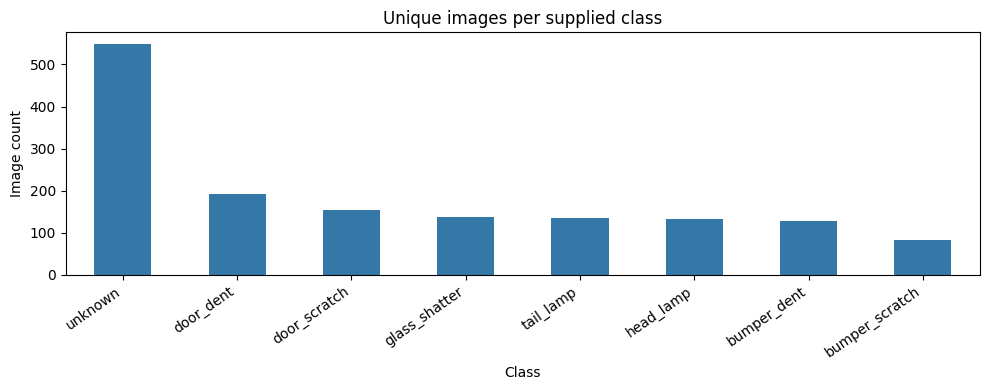

In [6]:
# Resolve the CSV's relative paths and verify all files are present.
def resolve_image_path(relative_path):
    path = DATA_ROOT / relative_path
    if not path.exists():
        # Supports CSV values that contain only a filename.
        path = IMAGE_DIR / Path(relative_path).name
    return path

df['path'] = df['image'].map(resolve_image_path)
missing = df.loc[~df['path'].map(Path.exists), 'image']
assert missing.empty, f'{len(missing)} image files are missing. Examples: {missing.head().tolist()}'

class_counts = df['classes'].value_counts().sort_values(ascending=False)
print(class_counts.to_string())
ax = class_counts.plot(kind='bar', figsize=(10, 4), color='#3478a8')
ax.set(title='Unique images per supplied class', xlabel='Class', ylabel='Image count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


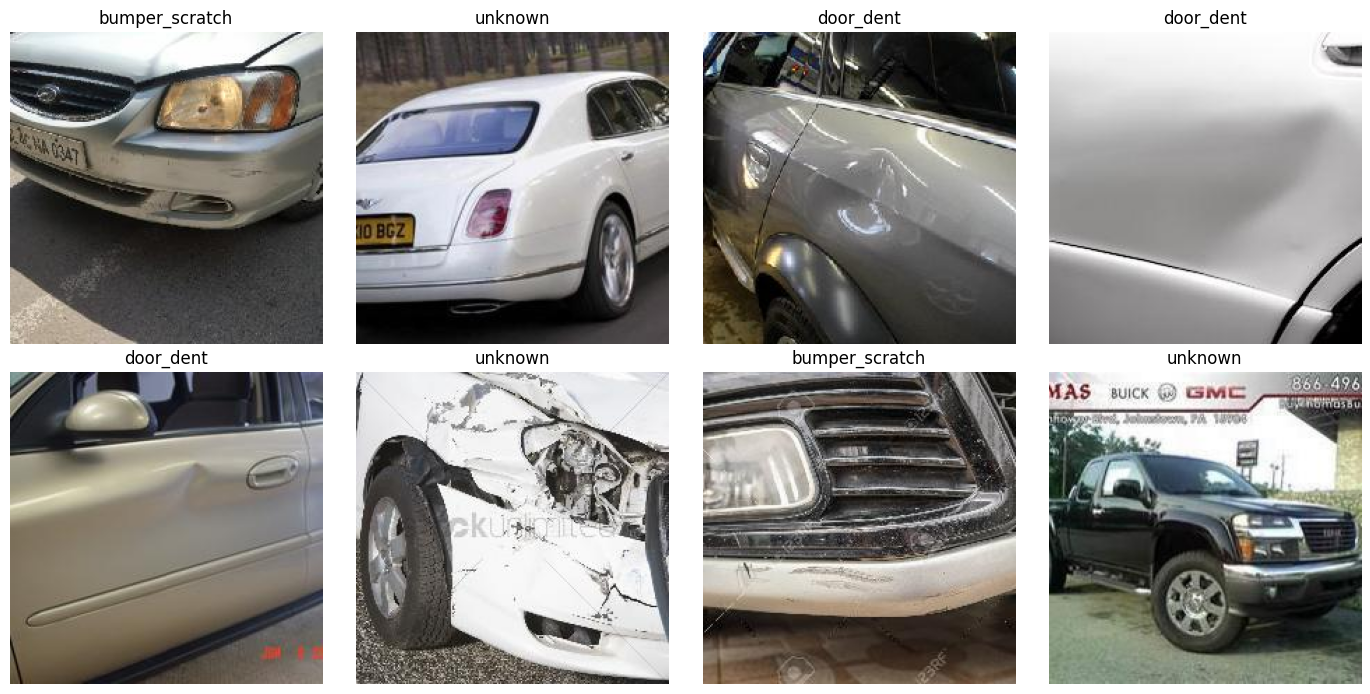

In [7]:
# Preview a few labeled examples.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (_, row) in zip(axes.flat, df.sample(min(8, len(df)), random_state=SEED).iterrows()):
    ax.imshow(Image.open(row['path']).convert('RGB'))
    ax.set_title(row['classes'])
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Split data and prepare image batches

We keep a stratified 70% training, 15% validation, and 15% test split. Stratification preserves class proportions as much as possible. The test split is set aside until final evaluation. Training images are resized and lightly augmented; validation and test images are only resized and normalized.

In [8]:
train_df, holdout_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['classes']
)
val_df, test_df = train_test_split(
    holdout_df, test_size=0.50, random_state=SEED, stratify=holdout_df['classes']
)

class_names = sorted(df['classes'].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
print(f'Train: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}')
print('Class-to-index mapping:', class_to_idx)


Train: 1,058 | Validation: 227 | Test: 227
Class-to-index mapping: {'bumper_dent': 0, 'bumper_scratch': 1, 'door_dent': 2, 'door_scratch': 3, 'glass_shatter': 4, 'head_lamp': 5, 'tail_lamp': 6, 'unknown': 7}


In [9]:
IMAGE_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

class CarDamageDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(row['path']).convert('RGB')
        image = self.transform(image)
        label = class_to_idx[row['classes']]
        return image, label

train_dataset = CarDamageDataset(train_df, train_transform)
val_dataset = CarDamageDataset(val_df, eval_transform)
test_dataset = CarDamageDataset(test_df, eval_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

images, labels = next(iter(train_loader))
print('Batch images:', tuple(images.shape), '| batch labels:', tuple(labels.shape))


Batch images: (32, 3, 128, 128) | batch labels: (32,)


## 4. Define the CNN

Each convolution block learns image patterns, applies batch normalization and ReLU, then halves width and height with max pooling. Adaptive average pooling produces a fixed-size feature vector regardless of input dimensions. Dropout helps reduce overfitting, and the last layer returns eight raw class scores.

In [10]:
class CarDamageCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CarDamageCNN(num_classes=len(class_names)).to(device)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


CarDamageCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1)

## 5. Train with validation monitoring

The class distribution is uneven, so we compute balanced class weights using only the training split. The optimizer updates model weights; validation loss tracks generalization and selects the checkpoint. Training stops early if validation loss does not improve for several epochs.

In [11]:
train_labels = train_df['classes'].map(class_to_idx).to_numpy()
weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(len(class_names)), y=train_labels
)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss, total = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    return total_loss / total

EPOCHS = 15
PATIENCE = 4
history = {'train_loss': [], 'val_loss': [], 'train_accuracy': []}
best_val_loss = float('inf')
best_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total
    val_loss = evaluate_loss(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_accuracy)
    print(f'Epoch {epoch+1:02}/{EPOCHS} | train loss {train_loss:.4f} | train acc {train_accuracy:.3f} | val loss {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print('Early stopping: validation loss did not improve.')
            break

model.load_state_dict(best_state)


Epoch 01/15 | train loss 1.9642 | train acc 0.274 | val loss 2.1337
Epoch 02/15 | train loss 1.8670 | train acc 0.320 | val loss 1.8621
Epoch 03/15 | train loss 1.8140 | train acc 0.306 | val loss 1.8463
Epoch 04/15 | train loss 1.7810 | train acc 0.390 | val loss 1.6984
Epoch 05/15 | train loss 1.7392 | train acc 0.356 | val loss 1.7075
Epoch 06/15 | train loss 1.7358 | train acc 0.325 | val loss 1.6547
Epoch 07/15 | train loss 1.7058 | train acc 0.348 | val loss 1.7536
Epoch 08/15 | train loss 1.6761 | train acc 0.383 | val loss 1.6165
Epoch 09/15 | train loss 1.6547 | train acc 0.384 | val loss 1.6593
Epoch 10/15 | train loss 1.6403 | train acc 0.403 | val loss 1.6391
Epoch 11/15 | train loss 1.6731 | train acc 0.388 | val loss 1.6632
Epoch 12/15 | train loss 1.6040 | train acc 0.400 | val loss 1.5597
Epoch 13/15 | train loss 1.5811 | train acc 0.433 | val loss 1.5622
Epoch 14/15 | train loss 1.5633 | train acc 0.402 | val loss 1.5291
Epoch 15/15 | train loss 1.5403 | train acc 0.40

<All keys matched successfully>

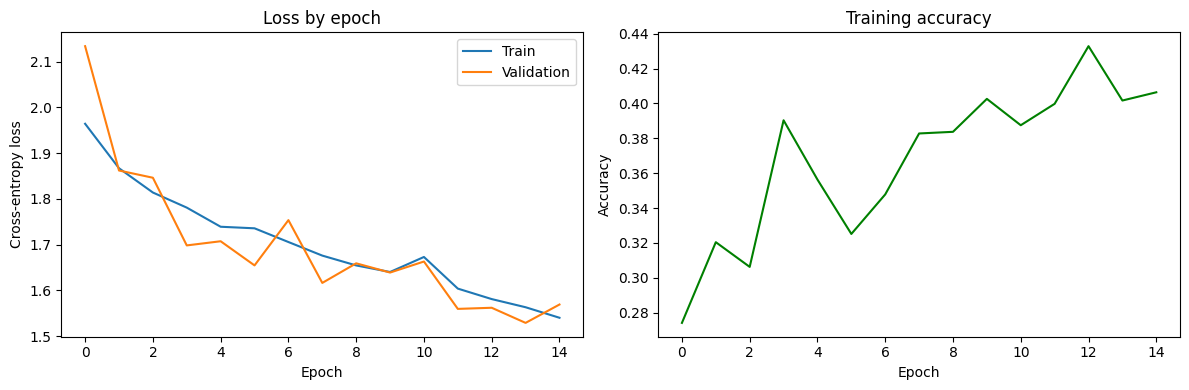

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set(title='Loss by epoch', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[0].legend()
axes[1].plot(history['train_accuracy'], color='green')
axes[1].set(title='Training accuracy', xlabel='Epoch', ylabel='Accuracy')
plt.tight_layout()
plt.show()


## 6. Final test-set evaluation

Run this after model selection. Accuracy is the fraction of correct predictions; macro F1 averages class-level F1 scores equally, which is useful when class sizes differ. Read the per-class precision/recall and confusion matrix to see which categories are confused.

In [13]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_true, all_pred = [], []
    for x, y in loader:
        logits = model(x.to(device))
        all_pred.extend(logits.argmax(dim=1).cpu().numpy())
        all_true.extend(y.numpy())
    return np.asarray(all_true), np.asarray(all_pred)

y_true, y_pred = predict_loader(model, test_loader)
print(f'Test accuracy: {accuracy_score(y_true, y_pred):.3f}')
print(f'Test macro F1: {f1_score(y_true, y_pred, average="macro"):.3f}')
print(classification_report(
    y_true, y_pred, labels=list(range(len(class_names))),
    target_names=class_names, zero_division=0
))


Test accuracy: 0.419
Test macro F1: 0.396
                precision    recall  f1-score   support

   bumper_dent       0.53      0.40      0.46        20
bumper_scratch       0.09      0.25      0.14        12
     door_dent       0.50      0.14      0.22        29
  door_scratch       0.36      0.57      0.44        23
 glass_shatter       0.57      0.65      0.60        20
     head_lamp       0.23      0.35      0.27        20
     tail_lamp       0.42      0.86      0.56        21
       unknown       0.74      0.35      0.48        82

      accuracy                           0.42       227
     macro avg       0.43      0.45      0.40       227
  weighted avg       0.53      0.42      0.42       227



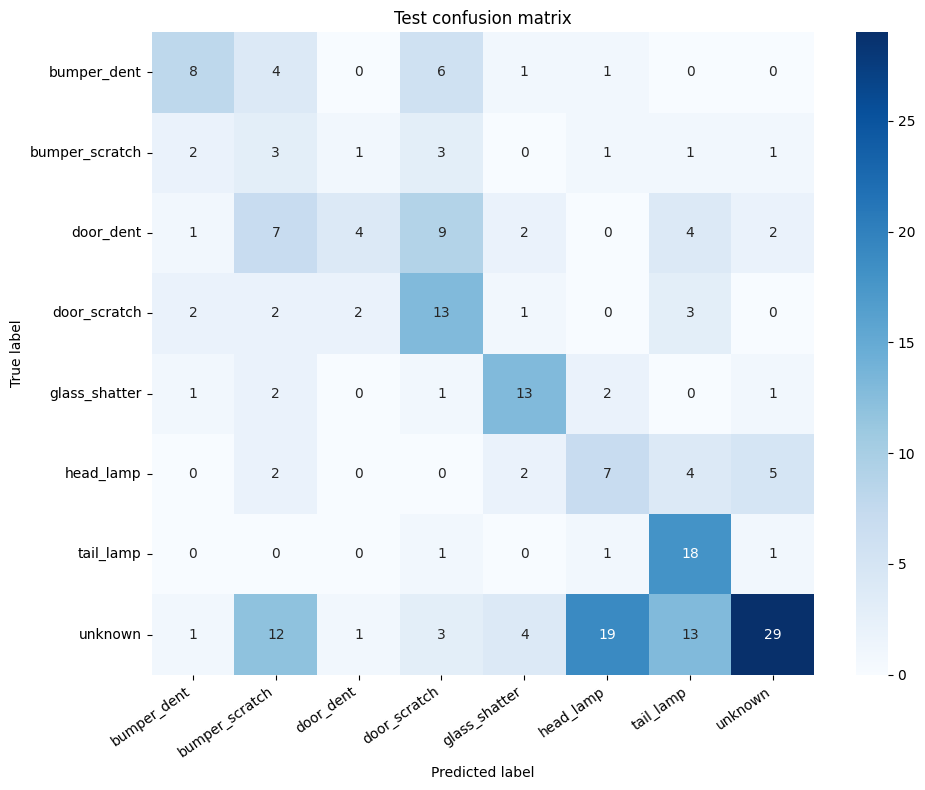

In [14]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


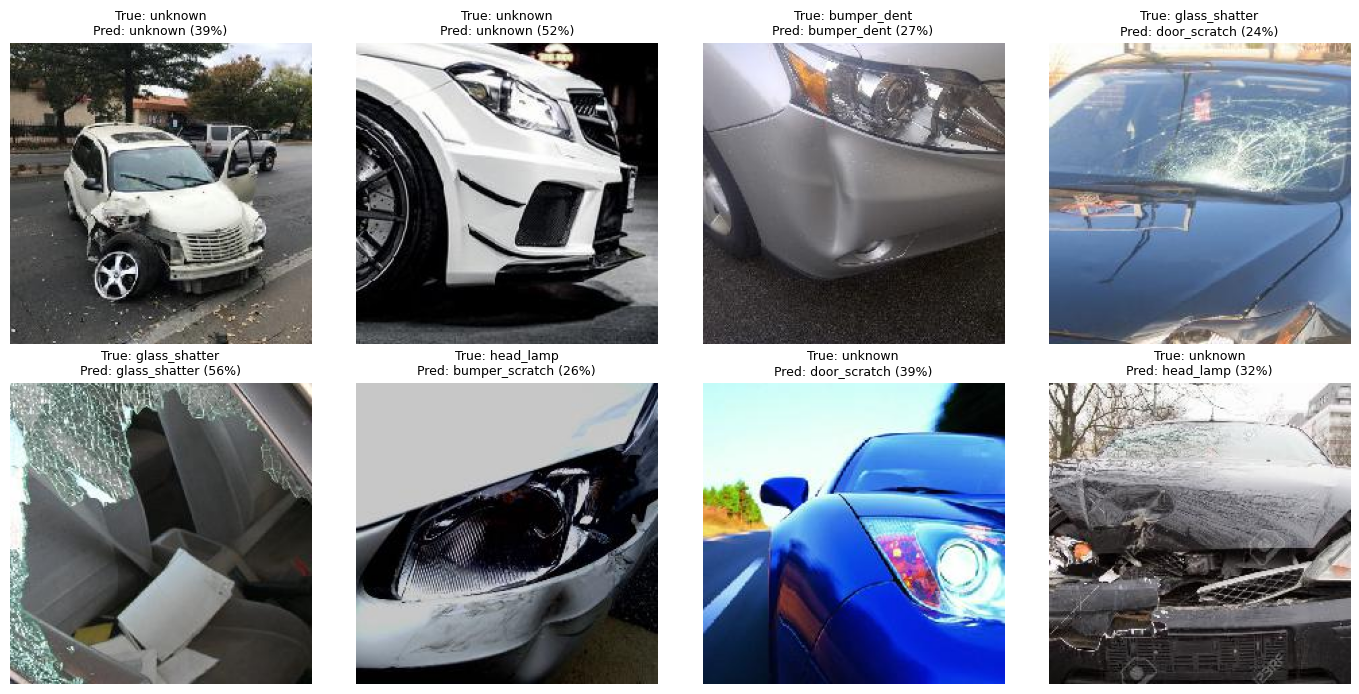

In [15]:
# Inspect randomly selected test predictions.
model.eval()
samples = test_df.sample(min(8, len(test_df)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, row in zip(axes.flat, samples.itertuples()):
    image = Image.open(row.path).convert('RGB')
    x = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probabilities = torch.softmax(model(x), dim=1)[0]
    pred_idx = int(probabilities.argmax().item())
    confidence = float(probabilities[pred_idx].item())
    ax.imshow(image)
    ax.set_title(f'True: {row.classes}\nPred: {idx_to_class[pred_idx]} ({confidence:.0%})', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 7. Findings and discussion (complete after running)

Record your actual run's results; do not copy example scores from another dataset.

- Best validation loss / epoch: **1.5291 at epoch 14**
- Test accuracy: **0.419 (41.9%)**
- Test macro F1: **0.396 (39.6%)**
- Classes with strongest recall: **tail_lamp, 0.86 (86%)**
- Most frequent confusions: **The classification report doesn’t show which classes were confused with each other. I’d need the confusion matrix to identify those pairs.**

### Limitations

- The supplied target labels describe damage/component types, not damage location or severity. The model cannot infer the missing categories reliably from absent labels.
- There are only about 1,500 unique images; performance may vary across vehicle types, lighting, camera angles, and real claim uploads.
- This is a single train/validation/test experiment. Results are not proof of production readiness, fairness, or financial impact.
- Predictions and confidence scores should support a qualified reviewer. They should not automatically approve, deny, or price a claim.

### Optional next steps

- Collect verified labels for the PDF's intended location and severity classes, then define the target taxonomy clearly.
- Compare this CNN with transfer learning (for example, a pretrained ResNet) using the same split.
- Use repeated stratified splits or cross-validation and evaluate calibration and class-specific costs.
- Save the trained model and class mapping together only after reviewing errors and validating on a separate source of images.